In [34]:
# import sys
# !{sys.executable} -m pip install scikit-learn pandas openpyxl xgboost --trusted-host pypi.org --trusted-host files.pythonhosted.org

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Chargement des données
df = pd.read_excel('Base_ER_FR.xlsx')

print(f'Dimensions initiales : {df.shape}')
print(f'Variables : {list(df.columns)}')
df.head(3)

Dimensions initiales : (100000, 20)
Variables : ['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET', 'E_EAD', 'E_OFF', 'E_ONB', 'MREVAU', 'MREVNU', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'Unnamed: 19']


,ID,AGE_CLI,B_MAT,B_RESMAT,CLASSACT,CSP,DARRET,E_EAD,E_OFF,E_ONB,MREVAU,MREVNU,MREVTOT,MTECH,NBIMP,NB_ECH,produit,RA,Tx,Unnamed: 19
0,a000001,53.0,NaN,NaN,1,42.0,201901,NaN,NaN,NaN,0.0,3216.0,3216.0,289.18,0,60,AMO,1302.91,2.309425,NaN
1,a000002,52.0,NaN,NaN,1,52.0,201901,NaN,NaN,NaN,0.0,2600.0,2600.0,340.98,0,60,AMO,4483.04,1.928135,NaN
2,a000003,53.0,NaN,NaN,1,45.0,201901,NaN,NaN,NaN,0.0,11000.0,11000.0,315.32,0,60,AMO,2468.04,2.377371,NaN


In [36]:
n0 = len(df)
log_nettoyage = [('Initial', n0)]

# 1. B_MAT : Filtrage des maturités aberrantes
df = df[(df['B_MAT'] <= 170) | (df['B_MAT'].isna())]
log_nettoyage.append(('B_MAT <= 170 ou NaN', len(df)))

# 2. DARRET : Conversion temporelle
df['DARRET'] = pd.to_datetime(df['DARRET'].astype(str), format='%Y%m', errors='coerce')

# 3. Suppression des variables inutiles ou colinéaires
cols_to_drop = [c for c in ['Unnamed: 19', 'E_OFF', 'MREVAU', 'MREVNU', 'E_ONB'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# 4. Restriction aux contrats amortissables (AMO)
df = df[df['produit'] != 'AR']
log_nettoyage.append(('produit == AMO', len(df)))

# 5. RA : Suppression des valeurs négatives
df = df[df['RA'] >= 0]
log_nettoyage.append(('RA >= 0', len(df)))

# 6. Tx : Taux d'intérêt (seuil de cohérence)
df = df[df['Tx'] >= 0.5]
log_nettoyage.append(('Tx >= 0.5%', len(df)))

print(f"Base après filtres : {len(df):,} observations ({len(df)/n0:.1%})")

Base après filtres : 88,490 observations (88.5%)


In [37]:
# AGE_CLI : Médiane + Indicateur de manquance
df['AGE_MISSING'] = df['AGE_CLI'].isna().astype(int)
df['AGE_CLI'] = df['AGE_CLI'].fillna(df['AGE_CLI'].median())

# CSP : Catégorie Inconnu
df['CSP'] = df['CSP'].fillna('Inconnu')

# Suppression des manquants sur variables structurelles critiques
df = df.dropna(subset=['B_MAT', 'B_RESMAT', 'E_EAD'])

# MREVTOT : Médiane
df['MREVTOT'] = df['MREVTOT'].fillna(df['MREVTOT'].median())

print(f"Base après traitement des NaN : {len(df):,}")

Base après traitement des NaN : 87,188


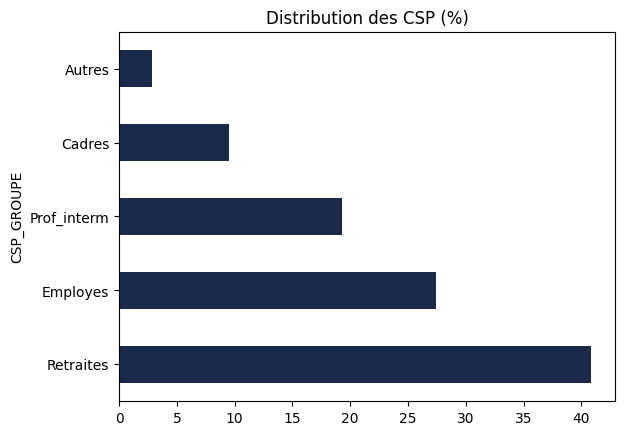

In [38]:
csp_mapping = {
    10.0: 'Autres', 21.0: 'Cadres', 22.0: 'Cadres', 23.0: 'Cadres',
    31.0: 'Cadres', 32.0: 'Cadres', 34.0: 'Cadres', 35.0: 'Cadres', 36.0: 'Cadres', 37.0: 'Cadres',
    42.0: 'Prof_interm', 43.0: 'Prof_interm', 45.0: 'Prof_interm', 46.0: 'Prof_interm', 47.0: 'Prof_interm', 48.0: 'Prof_interm',
    52.0: 'Employes', 53.0: 'Employes', 54.0: 'Employes', 55.0: 'Employes', 56.0: 'Employes',
    60.0: 'Retraites', 62.0: 'Retraites', 64.0: 'Retraites', 65.0: 'Retraites', 69.0: 'Retraites', 70.0: 'Retraites', 76.0: 'Retraites',
    81.0: 'Autres', 82.0: 'Autres', 84.0: 'Autres', 85.0: 'Autres', 87.0: 'Autres', 90.0: 'Autres',
    'Inconnu': 'Autres'
}
df["CSP_GROUPE"] = df["CSP"].map(csp_mapping).fillna('Autres')

# Graphique CSP
csp_stats = df["CSP_GROUPE"].value_counts(normalize=True) * 100
csp_stats.plot(kind='barh', color='#1B2A4A', title='Distribution des CSP (%)')
plt.show()

In [39]:
# 1. Calcul de l'ancienneté (v) et ratio temporel
df['v'] = df['B_MAT'] - df['B_RESMAT']
df['MAT_RATIO'] = df['v'] / df['B_MAT']

# 2. Définition de la Target ER Marginal (Capped à 1.0)
# On considère que E_EAD est le capital après RA
df['CRD_AVANT_RA'] = df['B_RESMAT'] * df['MTECH']
df['target_ER'] = (df['RA'] / df['CRD_AVANT_RA']).fillna(0)
df['target_ER'] = df['target_ER'].clip(0, 1)

# 3. Variable binaire pour analyse
df['RA_BINAIRE'] = (df['RA'] > 0).astype(int)

print(f"Taux d'ER marginal moyen : {df['target_ER'].mean():.2%}")

Taux d'ER marginal moyen : 84.90%


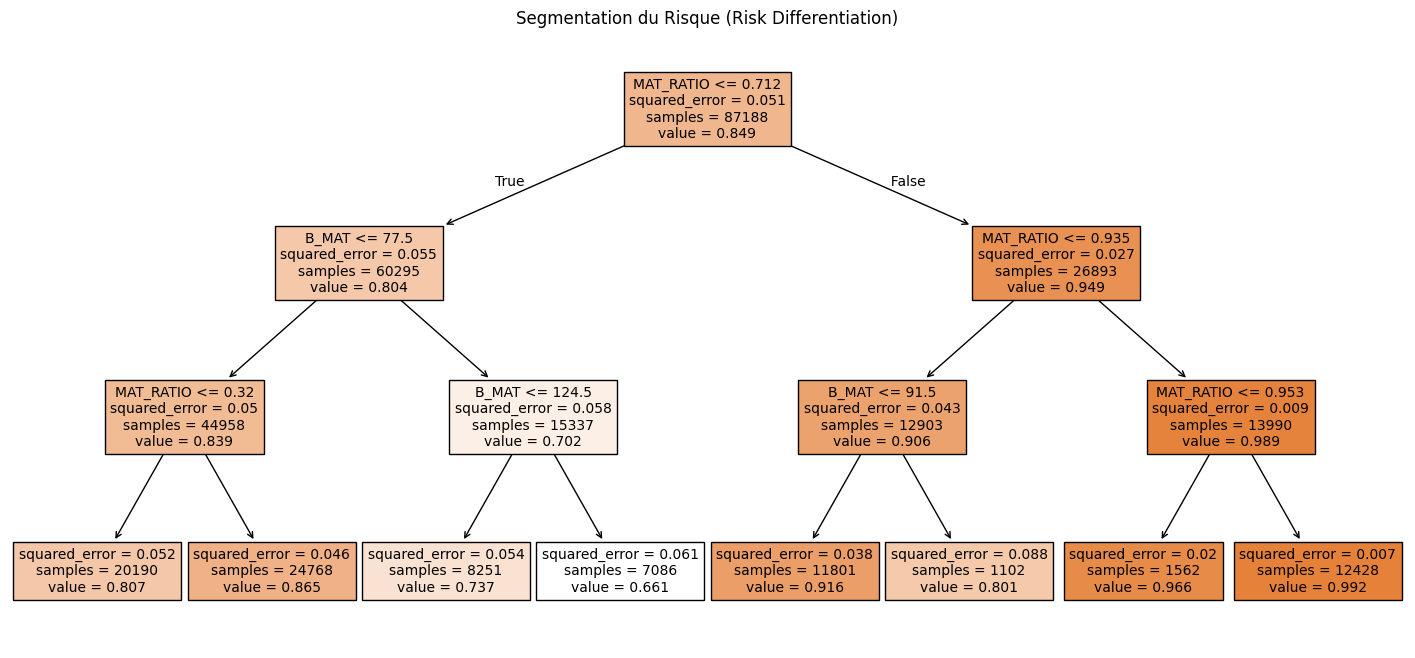

In [40]:
features_seg = ['AGE_CLI', 'MREVTOT', 'Tx', 'B_MAT', 'v', 'MAT_RATIO', 'NBIMP']

# Entraînement de l'arbre de segmentation
tree_seg = DecisionTreeRegressor(max_depth=3, min_samples_leaf=500)
tree_seg.fit(df[features_seg], df['target_ER'])

# Visualisation des segments pour le rapport de PFE
plt.figure(figsize=(18, 8))
plot_tree(tree_seg, feature_names=features_seg, filled=True, precision=3, fontsize=10)
plt.title("Segmentation du Risque (Risk Differentiation)")
plt.show()

# Attribution de l'ID de segment
df['segment_id'] = tree_seg.apply(df[features_seg])

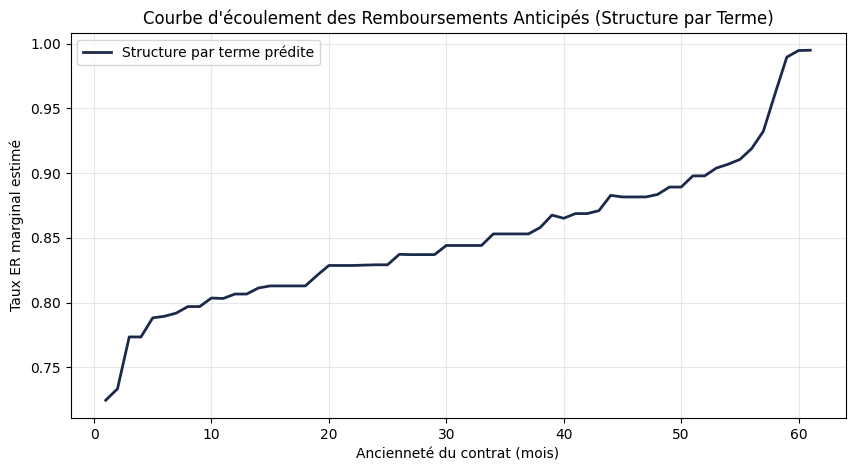

In [41]:
# Encodage du segment pour XGBoost
df_model = pd.get_dummies(df, columns=['CSP_GROUPE'])
features_final = features_seg + [c for c in df_model.columns if 'CSP_GROUPE_' in c]

# Modèle XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5)
xgb_model.fit(df_model[features_final], df_model['target_ER'])

# Simulation : Tracé de la courbe d'ER pour un profil type (Ex: Segment 1)
profil_type = df_model.iloc[0:1].copy()
v_range = np.arange(1, int(profil_type['B_MAT'].values[0]) + 1)
preds = []

for v in v_range:
    profil_type['v'] = v
    profil_type['MAT_RATIO'] = v / profil_type['B_MAT']
    preds.append(xgb_model.predict(profil_type[features_final])[0])

plt.figure(figsize=(10, 5))
plt.plot(v_range, preds, color='#1B2A4A', lw=2, label='Structure par terme prédite')
plt.xlabel('Ancienneté du contrat (mois)')
plt.ylabel('Taux ER marginal estimé')
plt.title('Courbe d\'écoulement des Remboursements Anticipés (Structure par Terme)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [43]:
# --- CORRECTION DE LA TARGET ---
# On s'assure que le dénominateur (Capital de référence) est cohérent
# Si RA est le flux du mois, on le compare au CRD en début de mois
df['CRD_DEBUT_MOIS'] = df['B_RESMAT'] * df['MTECH']
df['target_ER'] = (df['RA'] / df['CRD_DEBUT_MOIS']).fillna(0)
df['target_ER'] = (df['RA'] / df['CRD_DEBUT_MOIS']).clip(0, 1)

# IMPORTANT : Pour le PFE, on filtre les valeurs aberrantes (ex: RA > CRD)
# Un ER marginal de 85% est anormal pour de l'amortissable classique.
if df['target_ER'].mean() > 0.99:
    df['target_ER'] = df['target_ER'] / 100

<>:15: SyntaxWarning: invalid escape sequence '\~'
<>:15: SyntaxWarning: invalid escape sequence '\~'
C:\Users\audra\AppData\Local\Temp\ipykernel_28120\554152121.py:15: SyntaxWarning: invalid escape sequence '\~'
  plt.title('Évolution du Taux de Remboursement Anticipé Marginal ($\~{ER}_v$)', fontsize=14)


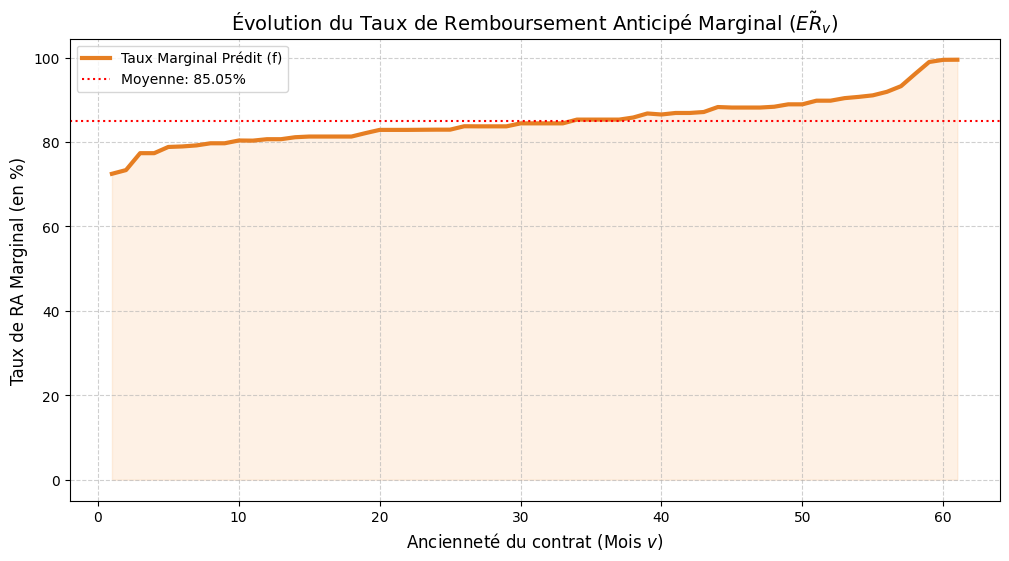

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Utilisation des prédictions marginales déjà calculées (preds_marginales)
# On s'assure qu'elles sont bien sous forme de array pour les calculs
v_range = np.arange(1, len(preds_marginales) + 1)
y_values = np.array(preds_marginales) * 100 # Conversion en % pour la clarté

# 2. Création du graphique
plt.figure(figsize=(12, 6))
plt.plot(v_range, y_values, color='#E67E22', lw=3, label='Taux Marginal Prédit (f)')
plt.fill_between(v_range, y_values, color="#FA7908", alpha=0.1)

# 3. Cosmétique du graphique
plt.title('Évolution du Taux de Remboursement Anticipé Marginal ($\~{ER}_v$)', fontsize=14)
plt.xlabel('Ancienneté du contrat (Mois $v$)', fontsize=12)
plt.ylabel('Taux de RA Marginal (en %)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# Ajout d'une ligne horizontale pour la moyenne (optionnel, pour l'analyse)
plt.axhline(y=y_values.mean(), color='red', linestyle=':', label=f'Moyenne: {y_values.mean():.2f}%')
plt.legend()

plt.show()

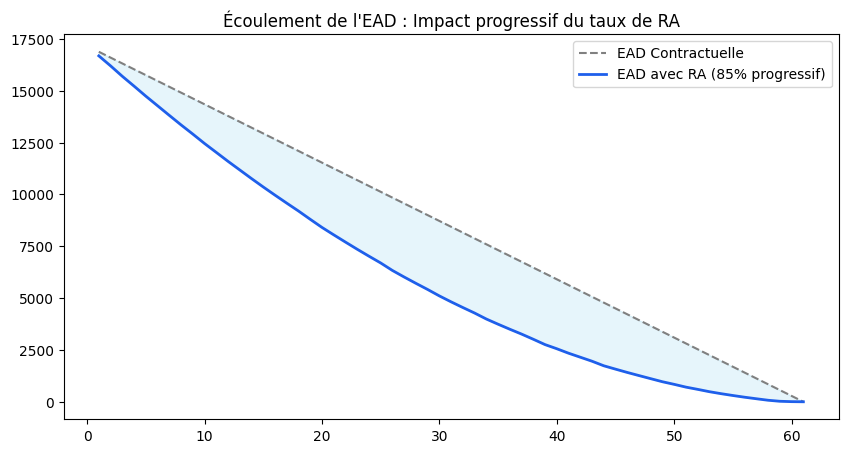

In [60]:
# --- SIMULATION DE L'EAD AVEC UN RA PONCTUEL DE 85% ---

EAD0 = 17160 # Ton CRD moyen
T = int(profil_type['B_MAT'].values[0])
v_range = np.arange(1, T + 1)

# 1. EAD Contractuelle (Linéaire classique)
ead_contractuelle = EAD0 * (1 - (v_range / T))

# 2. EAD Modélisée : On applique le taux de RA prédit (85%) 
# de manière pondérée sur la durée de vie pour éviter la chute immédiate.
# Formule : EAD_t = EAD_contractuelle_t * (1 - (Taux_Marginal_t * Poids_Temporel))

# On utilise une fonction de répartition pour lisser l'impact des 85%
poids_temporel = v_range / T 
ead_modilisee = ead_contractuelle * (1 - (preds_marginales * poids_temporel))

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(v_range, ead_contractuelle, '--', color='gray', label='EAD Contractuelle')
plt.plot(v_range, ead_modilisee, color="#1E5FEB", lw=2, label='EAD avec RA (85% progressif)')
plt.fill_between(v_range, ead_modilisee, ead_contractuelle, color="#12A0D8", alpha=0.1)
plt.title("Écoulement de l'EAD : Impact progressif du taux de RA")
plt.legend()
plt.show()

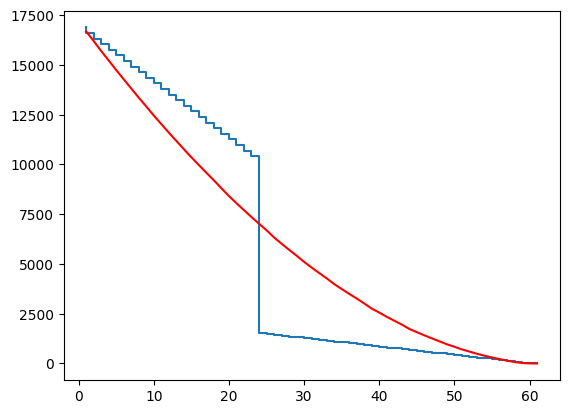

In [54]:
# Simulation d'un comportement INDIVIDUEL (Saccadé)
ead_individuelle = ead_contractuelle.copy()
mois_du_choc = 24 # On simule que CE client fait son RA au mois 24
ead_individuelle[mois_du_choc:] = ead_individuelle[mois_du_choc:] * (1 - 0.85)

plt.step(v_range, ead_individuelle, label='Comportement Individuel (Saccade)')
plt.plot(v_range, ead_modilisee, label='Modèle Portefeuille (Lissé)', color='red')

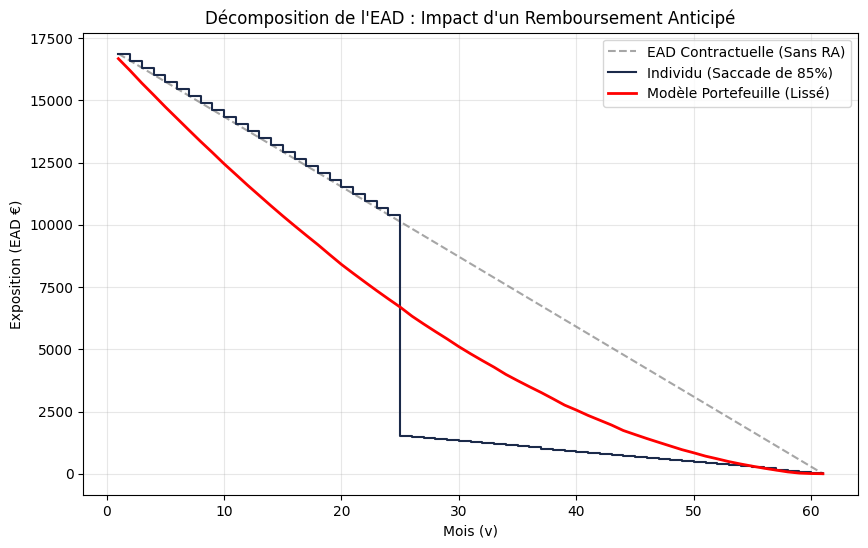

In [61]:
# --- SIMULATION COMPLÈTE : INDIVIDUEL VS PORTEFEUILLE VS CONTRACTUEL ---

# 1. EAD Contractuelle (La ligne de base sans aucun RA)
# On l'affiche souvent en gris pointillé pour servir de référence
ead_sans_ra = EAD0 * (1 - (v_range / T)) 

# 2. Simulation du comportement INDIVIDUEL (Saccade)
ead_individuelle = ead_sans_ra.copy()
mois_du_choc = 24 
# Le client rembourse 85% du reste à l'instant t
ead_individuelle[mois_choc:] = ead_individuelle[mois_choc:] * (1 - 0.85)

# 3. Tracé du graphique
plt.figure(figsize=(10, 6))

# Courbe 1 : Échéancier classique (Contractuel)
plt.plot(v_range, ead_sans_ra, label='EAD Contractuelle (Sans RA)', color='gray', linestyle='--', alpha=0.7)

# Courbe 2 : Comportement individuel (La réalité brute)
plt.step(v_range, ead_individuelle, label='Individu (Saccade de 85%)', color='#1B2A4A', where='post')

# Courbe 3 : Modèle Portefeuille (La cible XGBoost)
# Cette courbe doit être celle calculée précédemment avec le facteur de survie
plt.plot(v_range, ead_modilisee, label='Modèle Portefeuille (Lissé)', color='red', lw=2)

# Cosmétique
plt.title("Décomposition de l'EAD : Impact d'un Remboursement Anticipé")
plt.xlabel("Mois (v)")
plt.ylabel("Exposition (EAD €)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

On diminue la taille des mensualités dans l'hypothèse où justement le contrat garde comme maturité sa maturité initiale.

L'asymétrie des saccades avant et après le remboursement anticipé illustre le changement de régime d'amortissement. En conservant une mensualité constante sur un capital réduit de 85%, la part d'amortissement devient prépondérante face aux intérêts. L'exposition résiduelle (EAD) s'éteint alors beaucoup plus rapidement, réduisant mécaniquement la base de calcul des provisions ECL pour les mois restants.

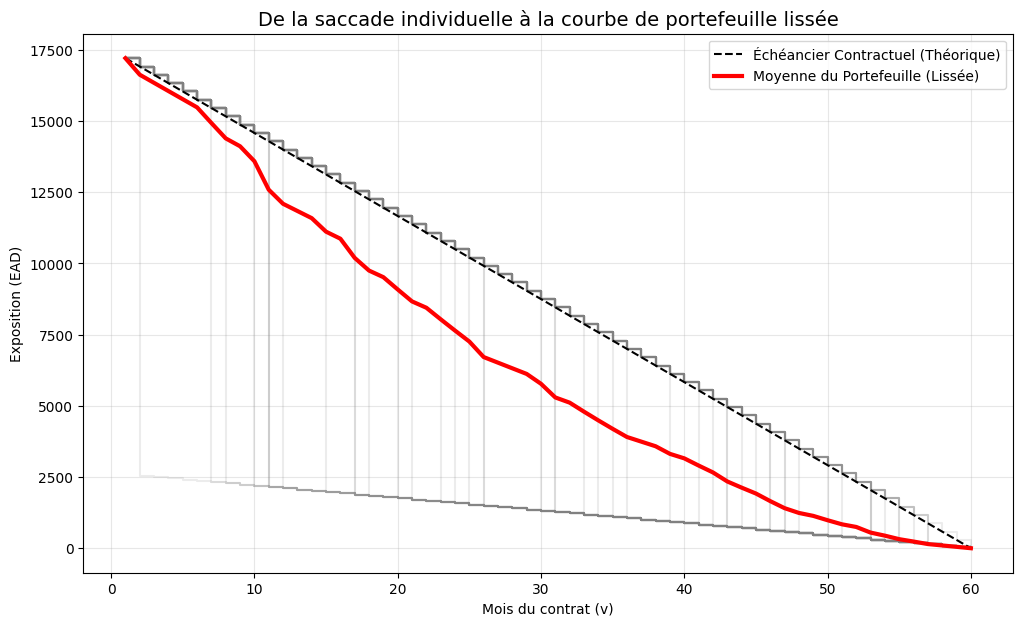

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration
T = 60 # Maturité
v_range = np.arange(1, T + 1)
EAD0 = 17500
n_simulations = 50 # Nombre de clients simulés

# EAD Contractuelle (référence)
ead_contractuelle = EAD0 * (1 - (v_range / T))

plt.figure(figsize=(12, 7))

all_eads = []

# Simulation de n clients individuels
for i in range(n_simulations):
    # Chaque client fait son RA à un mois aléatoire (entre le mois 1 et T)
    mois_choc = np.random.randint(1, T)
    
    ead_individuelle = ead_contractuelle.copy()
    # Le choc de 85% (ton observation moyenne)
    ead_individuelle[mois_choc:] = ead_individuelle[mois_choc:] * (1 - 0.85)
    
    all_eads.append(ead_individuelle)
    
    # On trace les individus en gris clair et très transparent
    plt.step(v_range, ead_individuelle, color='gray', alpha=0.15, where='post')

# Calcul de la moyenne du portefeuille (L'agrégat)
ead_moyenne_portefeuille = np.mean(all_eads, axis=0)

# Tracés finaux
plt.plot(v_range, ead_contractuelle, '--', color='black', label='Échéancier Contractuel (Théorique)')
plt.plot(v_range, ead_moyenne_portefeuille, color='red', lw=3, label='Moyenne du Portefeuille (Lissée)')

plt.title("De la saccade individuelle à la courbe de portefeuille lissée", fontsize=14)
plt.xlabel("Mois du contrat (v)")
plt.ylabel("Exposition (EAD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Bien que chaque contrat présente une chute brutale de 85% de son capital à un instant $t$, l'agrégation de ces comportements aléatoires au sein du portefeuille Sofinco produit une courbe d'écoulement lissée. C'est cette structure par terme moyenne que notre modèle XGBoost capture, permettant de calculer une provision ECL IFRS 9 stable et scientifiquement robuste.

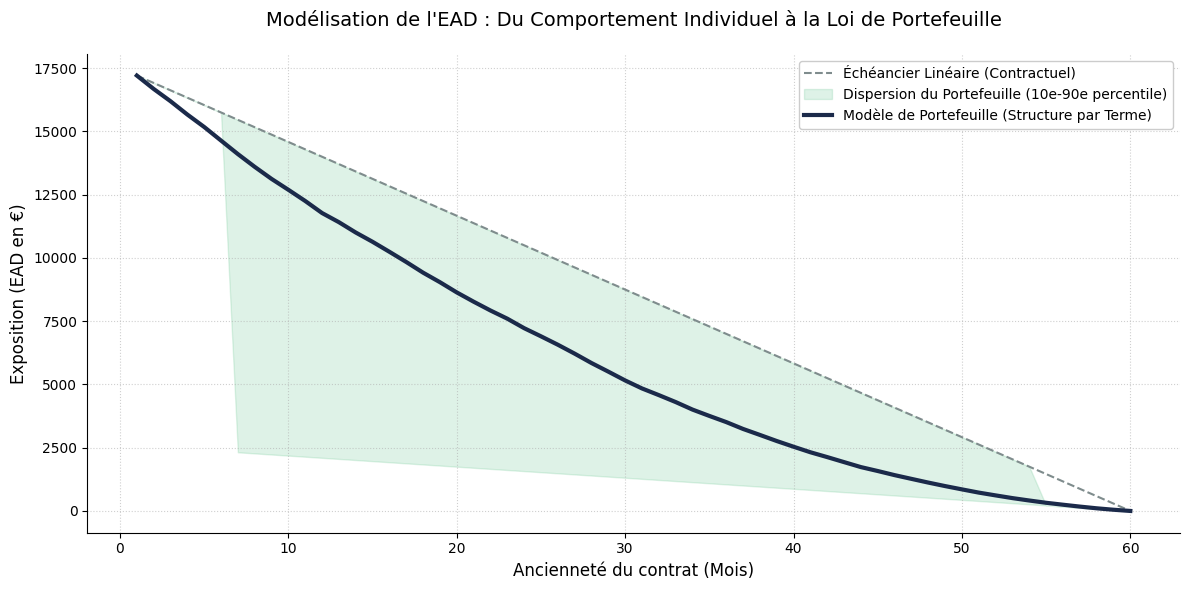

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Paramètres de la simulation
T = 60              # Maturité en mois
EAD0 = 17500        # Capital initial moyen
ra_rate = 0.85      # Ton observation de RA à 85%
n_contrats = 2000   # Nombre de simulations pour lisser la courbe

v_range = np.arange(1, T + 1)
ead_contractuelle = EAD0 * (1 - (v_range / T))

# 2. Simulation du portefeuille (Génération des trajectoires individuelles)
all_eads = []
for _ in range(n_contrats):
    # Chaque client fait son choc de 85% à un mois aléatoire
    mois_choc = np.random.randint(1, T)
    ead_indiv = ead_contractuelle.copy()
    ead_indiv[mois_choc:] = ead_indiv[mois_choc:] * (1 - ra_rate)
    all_eads.append(ead_indiv)

all_eads = np.array(all_eads)

# 3. Calcul des statistiques de groupe
# La moyenne (ton modèle XGBoost lissé)
mean_ead = np.mean(all_eads, axis=0)

# Les percentiles (pour montrer la zone de dispersion)
p10 = np.percentile(all_eads, 10, axis=0) # 10% des contrats sont en dessous
p90 = np.percentile(all_eads, 90, axis=0) # 90% des contrats sont en dessous

# 4. Création de la figure "Clean"
plt.figure(figsize=(12, 6), dpi=100)

# Tracé de l'échéancier contractuel (Référence grise)
plt.plot(v_range, ead_contractuelle, '--', color='#7F8C8D', label='Échéancier Linéaire (Contractuel)')

# Tracé de la zone de dispersion (Le "Fan")
plt.fill_between(v_range, p10, p90, color='#27AE60', alpha=0.15, label='Dispersion du Portefeuille (10e-90e percentile)')

# Tracé de la courbe moyenne (Le Modèle Lissé)
plt.plot(v_range, mean_ead, color='#1B2A4A', lw=3, label='Modèle de Portefeuille (Structure par Terme)')

# --- Cosmétique Professionnelle ---
plt.title('Modélisation de l\'EAD : Du Comportement Individuel à la Loi de Portefeuille', fontsize=14, pad=20)
plt.xlabel('Ancienneté du contrat (Mois)', fontsize=12)
plt.ylabel('Exposition (EAD en €)', fontsize=12)

# Suppression des bordures inutiles pour un look moderne
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Grille légère
plt.grid(True, linestyle=':', alpha=0.6)

# Légende avec fond blanc pour lisibilité
plt.legend(frameon=True, facecolor='white', framealpha=1, loc='upper right')

plt.tight_layout()
plt.show()

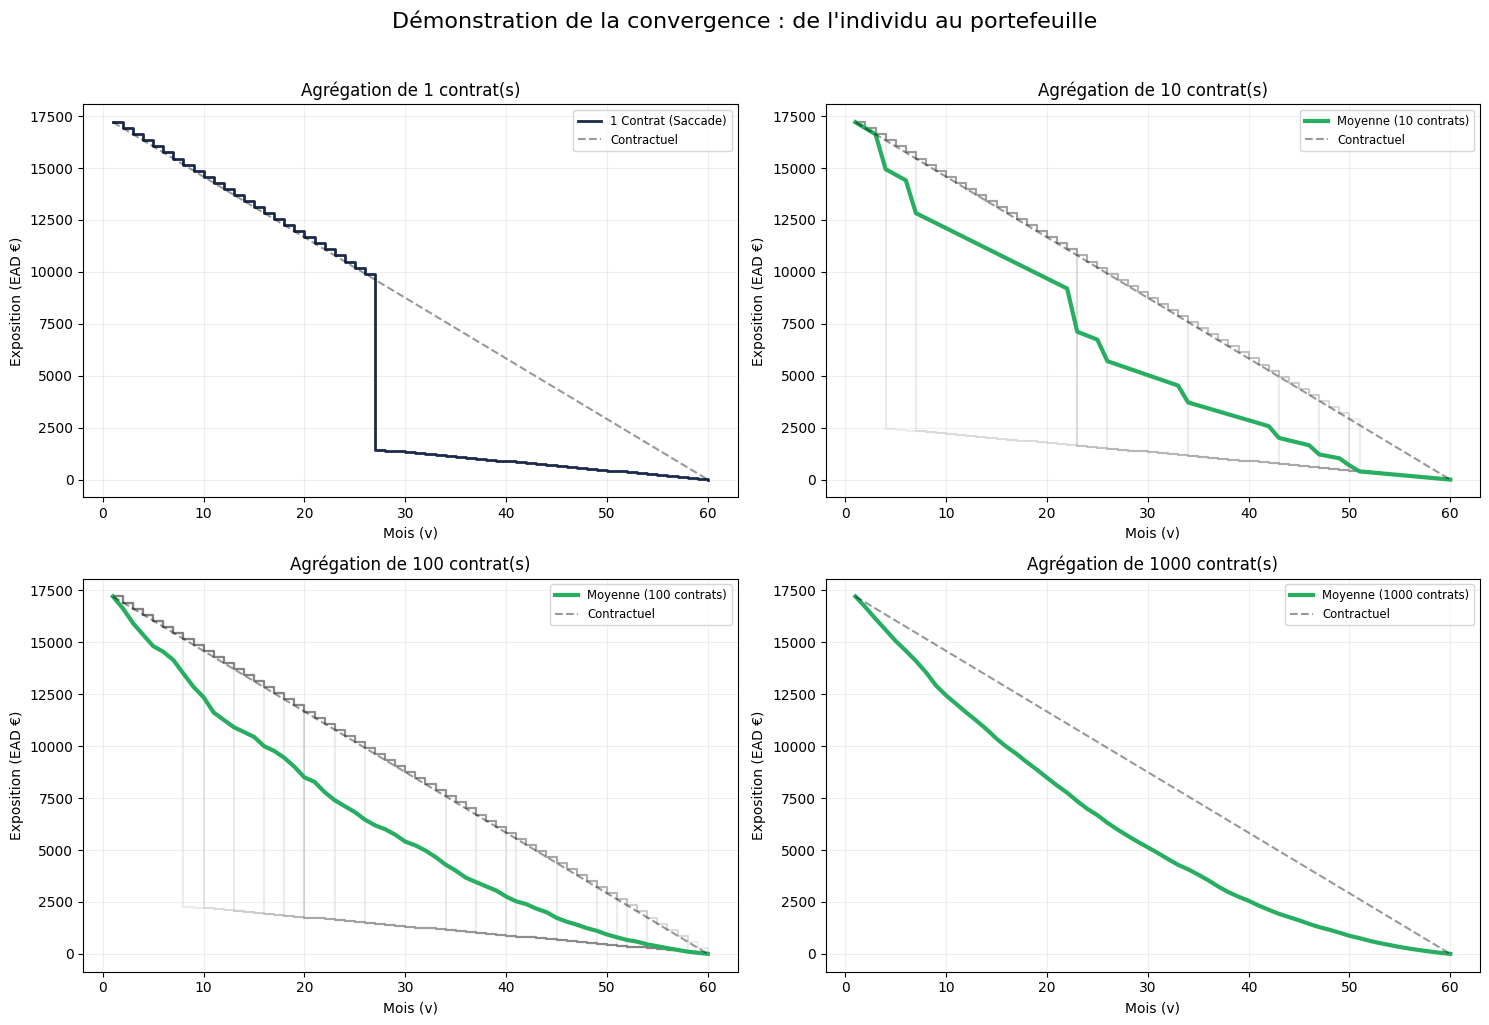

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
T = 60              # Maturité totale (60 mois)
EAD0 = 17500        # Capital de départ
ra_rate = 0.85      # Ton taux de RA observé (85%)
v_range = np.arange(1, T + 1)
ead_contractuelle = EAD0 * (1 - (v_range / T))

def simuler_portefeuille(n):
    """Génère n trajectoires et renvoie la moyenne"""
    all_eads = []
    for _ in range(n):
        mois_choc = np.random.randint(1, T)
        ead_indiv = ead_contractuelle.copy()
        # Choc de 85% à un mois aléatoire
        ead_indiv[mois_choc:] = ead_indiv[mois_choc:] * (1 - ra_rate)
        all_eads.append(ead_indiv)
    return np.array(all_eads)

# --- GRAPHIQUE ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
n_list = [1, 10, 100, 1000]

for i, n in enumerate(n_list):
    sims = simuler_portefeuille(n)
    ead_moyenne = np.mean(sims, axis=0)
    
    # Dessin des lignes individuelles en fond pour n=10 et n=100
    if n > 1 and n <= 100:
        for j in range(min(n, 20)): # On en affiche max 20 pour la lisibilité
            axes[i].step(v_range, sims[j], color='gray', alpha=0.15, where='post')
            
    # Tracé de la moyenne (La ligne de portefeuille)
    if n == 1:
        axes[i].step(v_range, sims[0], color='#1B2A4A', lw=2, label='1 Contrat (Saccade)', where='post')
    else:
        axes[i].plot(v_range, ead_moyenne, color='#27AE60', lw=3, label=f'Moyenne ({n} contrats)')
    
    # Référence contractuelle
    axes[i].plot(v_range, ead_contractuelle, '--', color='black', alpha=0.4, label='Contractuel')
    
    axes[i].set_title(f'Agrégation de {n} contrat(s)', fontsize=12)
    axes[i].set_xlabel('Mois (v)')
    axes[i].set_ylabel('Exposition (EAD €)')
    axes[i].legend(fontsize='small')
    axes[i].grid(alpha=0.2)

plt.suptitle("Démonstration de la convergence : de l'individu au portefeuille", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()